<a href="https://colab.research.google.com/github/Abdallah-Osama-cpp/heart-disease-prediction/blob/main/Copy_of_Heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv('train_data.csv') # train data
dt = pd.read_csv('test_data.csv')  # test data

In [40]:
df.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No
5,6,65.0,Female,4,120,177,0,0,140,0,0.4,1,0,7,Private,formerly smoked,No
6,7,56.0,Female,3,130,256,1,2,142,1,0.6,2,1,6,Private,never smoked,Yes
7,8,59.0,Female,4,110,239,0,2,142,1,1.2,2,1,7,Private,never smoked,Yes
8,9,60.0,Female,4,140,293,0,2,170,0,1.2,2,2,7,Private,Unknown,Yes
9,10,63.0,Male,4,150,407,0,2,154,0,4.0,2,3,7,Private,Unknown,Yes


In [41]:
dt.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,225,41.0,Male,2,130,204,0,2,172,0,1.4,1,0,3,Private,smokes,No
1,226,63.0,Male,3,135,252,0,2,172,0,0.0,1,0,3,Self-employed,never smoked,No
2,227,51.0,Female,3,94,227,0,0,154,1,0.0,1,1,7,Private,smokes,No
3,228,54.0,Female,3,120,258,0,2,147,0,0.4,2,0,7,Self-employed,smokes,No
4,229,44.0,Female,2,120,220,0,0,170,0,0.0,1,0,3,Govt_job,never smoked,No
5,230,54.0,Female,4,110,239,0,0,126,1,2.8,2,1,7,Private,smokes,Yes
6,231,65.0,Female,4,135,254,0,2,127,0,2.8,2,1,7,Private,never smoked,Yes
7,232,57.0,Female,3,150,168,0,0,174,0,1.6,1,0,3,Govt_job,formerly smoked,No
8,233,63.0,Female,4,130,330,1,2,132,1,1.8,1,3,7,Govt_job,smokes,Yes
9,235,35.0,Male,4,138,183,0,0,182,0,1.4,1,0,3,Private,smokes,No


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       224 non-null    int64  
 1   Age                      220 non-null    float64
 2   Gender                   218 non-null    object 
 3   Chest pain type          224 non-null    int64  
 4   BP                       224 non-null    int64  
 5   Cholesterol              224 non-null    int64  
 6   FBS over 120             224 non-null    int64  
 7   EKG results              224 non-null    int64  
 8   Max HR                   224 non-null    int64  
 9   Exercise angina          224 non-null    int64  
 10  ST depression            224 non-null    float64
 11  Slope of ST              224 non-null    int64  
 12  Number of vessels fluro  224 non-null    int64  
 13  Thallium                 224 non-null    int64  
 14  work_type                2

In [43]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56 non-null     int64  
 1   Age                      54 non-null     float64
 2   Gender                   56 non-null     object 
 3   Chest pain type          56 non-null     int64  
 4   BP                       56 non-null     int64  
 5   Cholesterol              56 non-null     int64  
 6   FBS over 120             56 non-null     int64  
 7   EKG results              56 non-null     int64  
 8   Max HR                   56 non-null     int64  
 9   Exercise angina          56 non-null     int64  
 10  ST depression            56 non-null     float64
 11  Slope of ST              56 non-null     int64  
 12  Number of vessels fluro  56 non-null     int64  
 13  Thallium                 56 non-null     int64  
 14  work_type                54 

In [44]:
df.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,224.000000,220.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,112.138393,54.550000,3.187500,130.700893,248.044643,0.151786,1.026786,149.245536,0.357143,1.025446,1.602679,0.696429,4.633929
std,64.671738,9.266833,0.961419,18.021034,51.895011,0.359617,0.997394,23.834396,0.480231,1.121668,0.626895,0.940749,1.936182
min,1.000000,29.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,56.750000,47.750000,3.000000,120.000000,212.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,112.500000,55.000000,3.000000,130.000000,242.500000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,168.250000,61.250000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.800000,2.000000,1.000000,7.000000
max,224.000000,77.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,3.000000,3.000000,7.000000


In [45]:
dt.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,56.000000,54.000000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,252.517857,53.722222,3.178571,133.625000,250.321429,0.125000,1.00000,152.696429,0.250000,1.153571,1.517857,0.571429,4.785714
std,16.289418,8.995631,0.876089,16.447782,49.633239,0.333712,1.00905,20.639697,0.436931,1.183364,0.602753,0.931414,1.951357
min,225.000000,35.000000,1.000000,94.000000,164.000000,0.000000,0.00000,97.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,238.750000,45.500000,3.000000,120.000000,210.500000,0.000000,0.00000,141.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,252.500000,54.000000,3.000000,132.000000,253.500000,0.000000,1.00000,154.500000,0.000000,1.000000,1.000000,0.000000,3.000000
75%,266.250000,60.750000,4.000000,140.000000,283.250000,0.000000,2.00000,170.250000,0.250000,1.600000,2.000000,1.000000,7.000000
max,280.000000,71.000000,4.000000,180.000000,353.000000,1.000000,2.00000,190.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [46]:
df = df.drop(columns=['id'])
dt = dt.drop(columns=['id'])

In [47]:
train_age_median = df['Age'].median()
train_gender_mode = df['Gender'].mode()[0]
train_work_mode = df['work_type'].mode()[0]
train_smoking_mode = df['smoking_status'].mode()[0]

df['Age'].fillna(train_age_median, inplace=True)
df['Gender'].fillna(train_gender_mode, inplace=True)
df['work_type'].fillna(train_work_mode, inplace=True)
df['smoking_status'].fillna(train_smoking_mode, inplace=True)

dt['Age'].fillna(train_age_median, inplace=True)
dt['work_type'].fillna(train_work_mode, inplace=True)
dt['smoking_status'].fillna(train_smoking_mode, inplace=True)

/tmp/ipykernel_11724/3870240921.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(train_age_median, inplace=True)
/tmp/ipykernel_11724/3870240921.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      224 non-null    float64
 1   Gender                   224 non-null    object 
 2   Chest pain type          224 non-null    int64  
 3   BP                       224 non-null    int64  
 4   Cholesterol              224 non-null    int64  
 5   FBS over 120             224 non-null    int64  
 6   EKG results              224 non-null    int64  
 7   Max HR                   224 non-null    int64  
 8   Exercise angina          224 non-null    int64  
 9   ST depression            224 non-null    float64
 10  Slope of ST              224 non-null    int64  
 11  Number of vessels fluro  224 non-null    int64  
 12  Thallium                 224 non-null    int64  
 13  work_type                224 non-null    object 
 14  smoking_status           2

In [49]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      56 non-null     float64
 1   Gender                   56 non-null     object 
 2   Chest pain type          56 non-null     int64  
 3   BP                       56 non-null     int64  
 4   Cholesterol              56 non-null     int64  
 5   FBS over 120             56 non-null     int64  
 6   EKG results              56 non-null     int64  
 7   Max HR                   56 non-null     int64  
 8   Exercise angina          56 non-null     int64  
 9   ST depression            56 non-null     float64
 10  Slope of ST              56 non-null     int64  
 11  Number of vessels fluro  56 non-null     int64  
 12  Thallium                 56 non-null     int64  
 13  work_type                56 non-null     object 
 14  smoking_status           56 

In [50]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No


In [51]:
df['Gender'].unique()


array(['Female', 'Male'], dtype=object)

In [52]:
dt['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [53]:
df['smoking_status'].unique()


array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [54]:
dt['smoking_status'].unique()

array(['smokes', 'never smoked', 'formerly smoked', 'Unknown'],
      dtype=object)

In [55]:
df['work_type'].unique()


array(['Private', 'Self-employed', 'Govt_job', 'children'], dtype=object)

In [56]:
dt['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [57]:
df['Heart Disease'].unique()


array(['Yes', 'No'], dtype=object)

In [58]:
dt['Heart Disease'].unique()

array(['No', 'Yes'], dtype=object)

In [59]:
df['Heart Disease'] = df['Heart Disease'].map({'No': 0, 'Yes': 1})
dt['Heart Disease'] = dt['Heart Disease'].map({'No': 0, 'Yes': 1})

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
dt['Gender'] = dt['Gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df, columns=['smoking_status', 'work_type'], drop_first=False)
dt = pd.get_dummies(dt, columns=['smoking_status', 'work_type'], drop_first=False)

dt = dt.reindex(columns=df.columns, fill_value=0)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
dt[bool_cols] = dt[bool_cols].astype(int)


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             224 non-null    float64
 1   Gender                          224 non-null    int64  
 2   Chest pain type                 224 non-null    int64  
 3   BP                              224 non-null    int64  
 4   Cholesterol                     224 non-null    int64  
 5   FBS over 120                    224 non-null    int64  
 6   EKG results                     224 non-null    int64  
 7   Max HR                          224 non-null    int64  
 8   Exercise angina                 224 non-null    int64  
 9   ST depression                   224 non-null    float64
 10  Slope of ST                     224 non-null    int64  
 11  Number of vessels fluro         224 non-null    int64  
 12  Thallium                        224 

In [61]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             56 non-null     float64
 1   Gender                          56 non-null     int64  
 2   Chest pain type                 56 non-null     int64  
 3   BP                              56 non-null     int64  
 4   Cholesterol                     56 non-null     int64  
 5   FBS over 120                    56 non-null     int64  
 6   EKG results                     56 non-null     int64  
 7   Max HR                          56 non-null     int64  
 8   Exercise angina                 56 non-null     int64  
 9   ST depression                   56 non-null     float64
 10  Slope of ST                     56 non-null     int64  
 11  Number of vessels fluro         56 non-null     int64  
 12  Thallium                        56 non

In [62]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Thallium,Heart Disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,70.0,0,4,130,322,0,2,109,0,2.4,...,3,1,0,1,0,0,0,1,0,0
1,67.0,1,3,115,564,0,2,160,0,1.6,...,7,0,0,0,1,0,0,0,1,0
2,57.0,0,2,124,261,0,0,141,0,0.3,...,7,1,0,0,1,0,0,1,0,0
3,64.0,0,4,128,263,0,0,105,1,0.2,...,7,0,0,0,0,1,0,1,0,0
4,74.0,1,2,120,269,0,2,121,1,0.2,...,3,0,0,0,1,0,0,0,1,0


### Separate features (X) and target (y)

In [63]:
X_train = df.drop('Heart Disease', axis=1)
y_train = df['Heart Disease']

X_test = dt.drop('Heart Disease', axis=1)
y_test = dt['Heart Disease']

### Scaling Numerical Features

I will use `StandardScaler` to scale the numerical features. This is a common preprocessing step that standardizes features by removing the mean and scaling to unit variance. This ensures that features with larger values do not disproportionately influence the model's performance. The scaler will be fit on the training data (`X_train`) and then used to transform both the training and testing data (`X_test`) to prevent data leakage.

In [64]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,1.685249,0,4,-0.038980,1.428287,0,2,-1.692330,0,1.228200,...,3,3,0,1,0,0,0,1,0,0
1,1.357846,1,3,-0.873205,6.101993,0,2,0.452227,0,0.513379,...,0,7,0,0,1,0,0,0,1,0
2,0.266502,0,2,-0.372670,0.250205,0,0,-0.346726,0,-0.648205,...,0,7,0,0,1,0,0,1,0,0
3,1.030443,0,4,-0.150210,0.288830,0,0,-1.860531,1,-0.737558,...,1,7,0,0,0,1,0,1,0,0
4,2.121786,1,2,-0.595130,0.404707,0,2,-1.187729,1,-0.737558,...,1,3,0,0,1,0,0,0,1,0


Visualizing Outliers with Box Plots

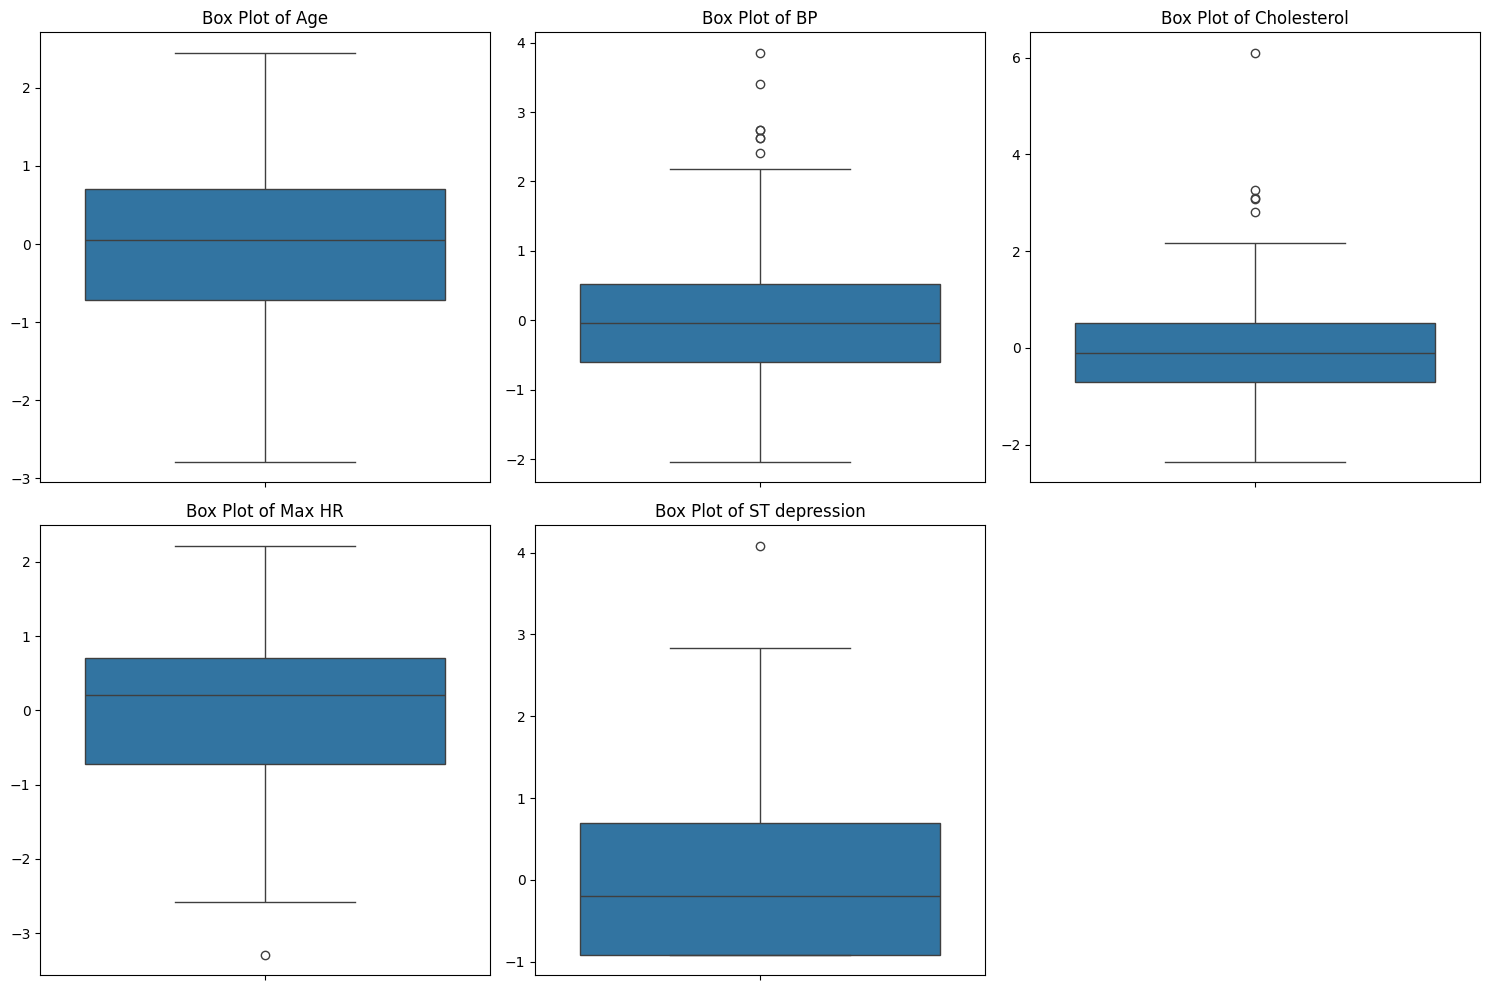

In [65]:


plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Identifying Outlier Indices using IQR

In [66]:
outlier_indices = {}
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)].index.tolist()
    outlier_indices[col] = col_outliers

    print(f"Column: {col}")
    print(f"  Number of outliers: {len(col_outliers)}")
    print(f"  Outlier indices: {col_outliers}\n")

Column: Age
  Number of outliers: 0
  Outlier indices: []

Column: BP
  Number of outliers: 7
  Outlier indices: [58, 87, 110, 117, 153, 168, 174]

Column: Cholesterol
  Number of outliers: 5
  Outlier indices: [1, 9, 52, 190, 197]

Column: Max HR
  Number of outliers: 1
  Outlier indices: [101]

Column: ST depression
  Number of outliers: 1
  Outlier indices: [165]



Capping Outliers using IQR

In [67]:
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in X_train
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Cap outliers in X_test using bounds from X_train
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped successfully in X_train and X_test.")

display(X_train.head())
display(X_test.head())

Outliers capped successfully in X_train and X_test.


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,1.685249,0,4,-0.038980,1.428287,0,2,-1.692330,0,1.228200,...,3,3,0,1,0,0,0,1,0,0
1,1.357846,1,3,-0.873205,2.345647,0,2,0.452227,0,0.513379,...,0,7,0,0,1,0,0,0,1,0
2,0.266502,0,2,-0.372670,0.250205,0,0,-0.346726,0,-0.648205,...,0,7,0,0,1,0,0,1,0,0
3,1.030443,0,4,-0.150210,0.288830,0,0,-1.860531,1,-0.737558,...,1,7,0,0,0,1,0,1,0,0
4,2.121786,1,2,-0.595130,0.404707,0,2,-1.187729,1,-0.737558,...,1,3,0,0,1,0,0,0,1,0


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,-1.479647,1,2,-0.038980,-0.850627,0,2,0.956828,0,0.334673,...,0,3,0,0,0,1,0,1,0,0
1,0.921308,1,3,0.239095,0.076389,0,2,0.956828,0,-0.916263,...,0,3,0,0,1,0,0,0,1,0
2,-0.388304,0,3,-2.041120,-0.406432,0,0,0.199926,1,-0.916263,...,1,7,0,0,0,1,0,1,0,0
3,-0.060901,0,3,-0.595130,0.192266,0,2,-0.094425,0,-0.558853,...,0,7,0,0,0,1,0,0,1,0
4,-1.152244,0,2,-0.595130,-0.541621,0,0,0.872728,0,-0.916263,...,0,3,0,0,1,0,1,0,0,0


Visualizing Outliers after Capping with Box Plots

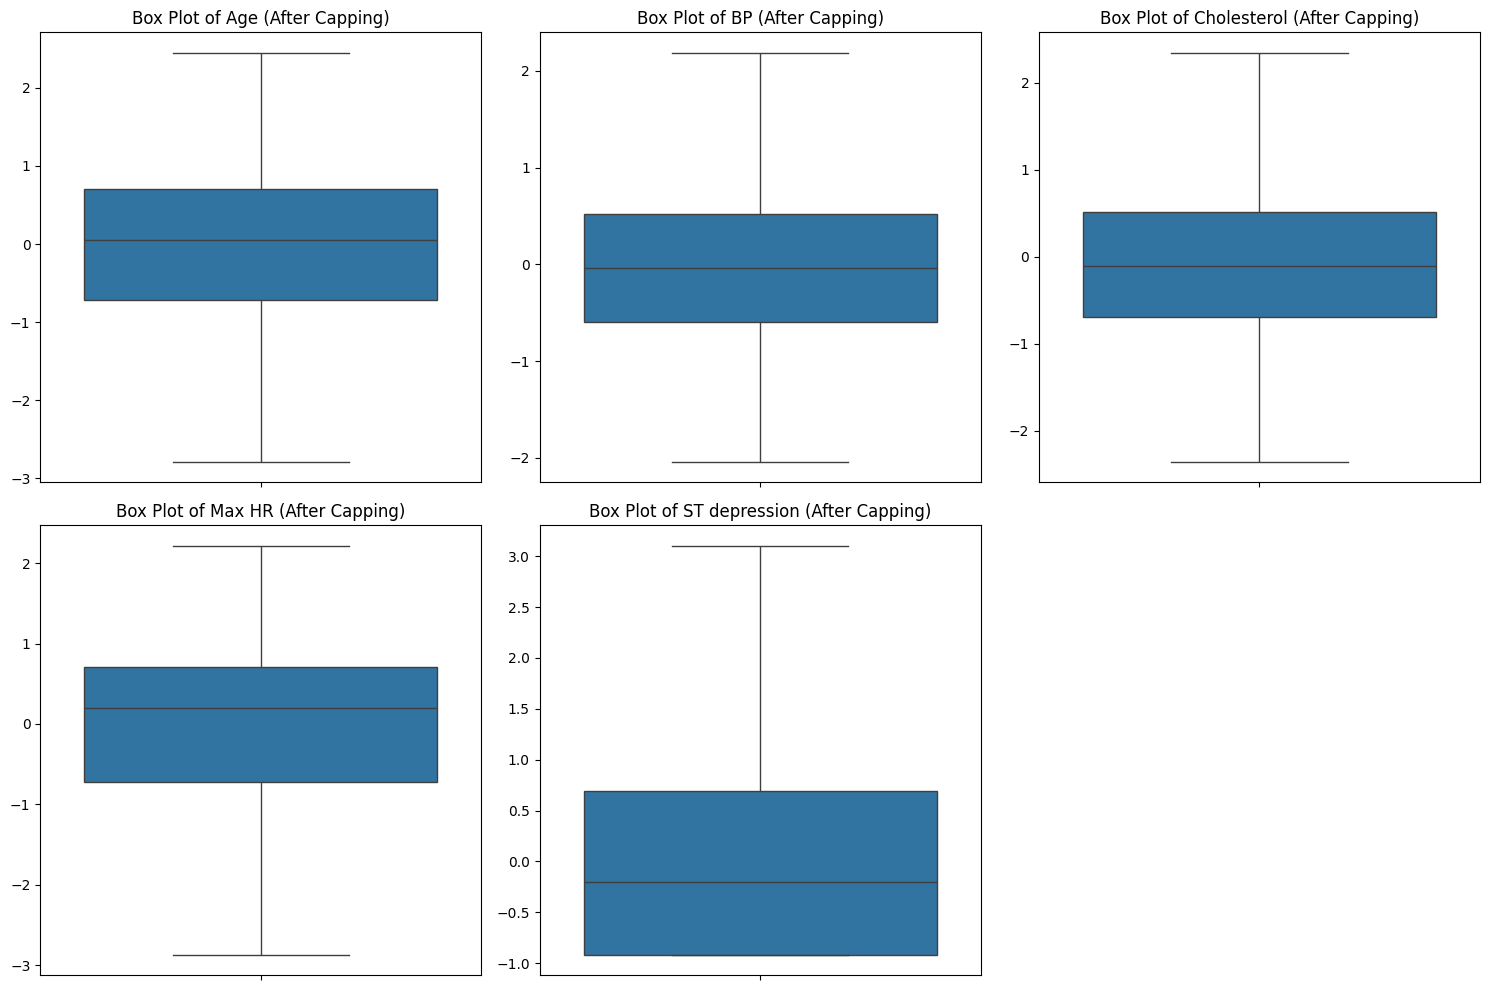

In [68]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()